In [2]:


# Numerical operations
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Statistical visualization
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Statistical regression and diagnostic tests
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Plot settings
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")



All libraries imported successfully.


In [3]:





# Set a random seed so that the same data is generated every time
np.random.seed(42)

# Number of students
number_of_students = 500

# Generate student IDs
student_id = np.arange(1, number_of_students + 1)

# Study hours per day: between approximately 0.5 and 10 hours
study_hours = np.random.normal(loc=4.5, scale=1.8, size=number_of_students)
study_hours = np.clip(study_hours, 0.5, 10)

# Attendance percentage: between 40% and 100%
attendance = np.random.normal(loc=78, scale=12, size=number_of_students)
attendance = np.clip(attendance, 40, 100)

# Assignment score: between 35 and 100
assignment_score = np.random.normal(
    loc=72,
    scale=13,
    size=number_of_students
)
assignment_score = np.clip(assignment_score, 35, 100)

# Sleep hours per day: between 3 and 10
sleep_hours = np.random.normal(loc=6.8, scale=1.2, size=number_of_students)
sleep_hours = np.clip(sleep_hours, 3, 10)

# Non-academic internet usage: between 0 and 10 hours per day
internet_hours = np.random.normal(loc=4, scale=1.8, size=number_of_students)
internet_hours = np.clip(internet_hours, 0, 10)

# Monthly family income in Nepalese rupees
family_income = np.random.lognormal(
    mean=np.log(60000),
    sigma=0.55,
    size=number_of_students
)
family_income = np.clip(family_income, 15000, 300000)

# Previous GPA: between 1.8 and 4.0
previous_gpa = np.random.normal(loc=3.0, scale=0.45, size=number_of_students)
previous_gpa = np.clip(previous_gpa, 1.8, 4.0)

# Extracurricular activity: Yes or No
extracurricular = np.random.choice(
    ["Yes", "No"],
    size=number_of_students,
    p=[0.45, 0.55]
)

# Convert extracurricular participation into a numerical effect
extracurricular_effect = np.where(extracurricular == "Yes", 0.08, 0)

# Random error represents factors not included in the dataset
random_error = np.random.normal(loc=0, scale=0.18, size=number_of_students)

# Generate CGPA using a realistic mathematical relationship
cgpa = (
    0.35
    + 0.085 * study_hours
    + 0.008 * attendance
    + 0.006 * assignment_score
    + 0.055 * sleep_hours
    - 0.035 * internet_hours
    + 0.0000008 * family_income
    + 0.42 * previous_gpa
    + extracurricular_effect
    + random_error
)

# Keep CGPA within a realistic 0 to 4 scale
cgpa = np.clip(cgpa, 1.5, 4.0)

# Create the dataframe
df = pd.DataFrame({
    "Student_ID": student_id,
    "Study_Hours": study_hours,
    "Attendance": attendance,
    "Assignment_Score": assignment_score,
    "Sleep_Hours": sleep_hours,
    "Internet_Hours": internet_hours,
    "Family_Income": family_income,
    "Previous_GPA": previous_gpa,
    "Extracurricular": extracurricular,
    "CGPA": cgpa
})

# Round values for readability
df["Study_Hours"] = df["Study_Hours"].round(2)
df["Attendance"] = df["Attendance"].round(2)
df["Assignment_Score"] = df["Assignment_Score"].round(2)
df["Sleep_Hours"] = df["Sleep_Hours"].round(2)
df["Internet_Hours"] = df["Internet_Hours"].round(2)
df["Family_Income"] = df["Family_Income"].round(0)
df["Previous_GPA"] = df["Previous_GPA"].round(2)
df["CGPA"] = df["CGPA"].round(2)

print("Dataset created successfully.")
print("Dataset shape:", df.shape)

df.head(10)




Dataset created successfully.
Dataset shape: (500, 10)


,Student_ID,Study_Hours,Attendance,Assignment_Score,Sleep_Hours,Internet_Hours,Family_Income,Previous_GPA,Extracurricular,CGPA
0,1,5.390,89.110,90.190,7.730,2.780,82120.000,2.140,Yes,3.460
1,2,4.250,100.000,84.020,6.140,3.740,102191.000,2.610,No,3.550
2,3,5.670,61.220,72.780,5.820,2.570,50005.000,2.810,No,3.330
3,4,7.240,84.760,63.590,6.800,3.450,42846.000,3.850,Yes,4.000
4,5,4.080,70.190,81.080,6.600,0.590,33033.000,3.250,No,3.330
5,6,4.080,72.150,77.120,6.260,4.380,38106.000,2.400,No,2.620
6,7,7.340,70.890,83.640,7.640,4.000,300000.000,3.220,Yes,3.920
7,8,5.880,67.630,80.260,7.950,2.530,118976.000,2.300,Yes,3.540
8,9,3.650,78.580,85.640,6.910,5.190,28538.000,3.490,Yes,3.820
9,10,5.480,68.030,65.040,8.570,5.690,28991.000,2.790,No,3.340


In [4]:



df




,Student_ID,Study_Hours,Attendance,Assignment_Score,Sleep_Hours,Internet_Hours,Family_Income,Previous_GPA,Extracurricular,CGPA
0,1,5.390,89.110,90.190,7.730,2.780,82120.000,2.140,Yes,3.460
1,2,4.250,100.000,84.020,6.140,3.740,102191.000,2.610,No,3.550
2,3,5.670,61.220,72.780,5.820,2.570,50005.000,2.810,No,3.330
3,4,7.240,84.760,63.590,6.800,3.450,42846.000,3.850,Yes,4.000
4,5,4.080,70.190,81.080,6.600,0.590,33033.000,3.250,No,3.330
...,...,...,...,...,...,...,...,...,...,...
495,496,5.470,74.630,98.080,8.080,5.460,62612.000,3.870,Yes,4.000
496,497,2.630,99.570,98.800,6.770,3.500,69138.000,3.370,No,3.570
497,498,4.160,85.690,87.710,5.740,3.500,30307.000,2.980,Yes,3.390
498,499,2.920,71.150,85.310,6.600,5.420,72106.000,2.920,No,3.010


In [5]:



# Save the dataset as a CSV file
df.to_csv("student_cgpa_dataset.csv", index=False)

print("Dataset saved as student_cgpa_dataset.csv")




Dataset saved as student_cgpa_dataset.csv


In [6]:
print("First five records:")
display(df.head())

First five records:


,Student_ID,Study_Hours,Attendance,Assignment_Score,Sleep_Hours,Internet_Hours,Family_Income,Previous_GPA,Extracurricular,CGPA
0,1,5.390,89.110,90.190,7.730,2.780,82120.000,2.140,Yes,3.460
1,2,4.250,100.000,84.020,6.140,3.740,102191.000,2.610,No,3.550
2,3,5.670,61.220,72.780,5.820,2.570,50005.000,2.810,No,3.330
3,4,7.240,84.760,63.590,6.800,3.450,42846.000,3.850,Yes,4.000
4,5,4.080,70.190,81.080,6.600,0.590,33033.000,3.250,No,3.330


In [7]:




print("\nLast five records:")
display(df.tail())





Last five records:


,Student_ID,Study_Hours,Attendance,Assignment_Score,Sleep_Hours,Internet_Hours,Family_Income,Previous_GPA,Extracurricular,CGPA
495,496,5.470,74.630,98.080,8.080,5.460,62612.000,3.870,Yes,4.000
496,497,2.630,99.570,98.800,6.770,3.500,69138.000,3.370,No,3.570
497,498,4.160,85.690,87.710,5.740,3.500,30307.000,2.980,Yes,3.390
498,499,2.920,71.150,85.310,6.600,5.420,72106.000,2.920,No,3.010
499,500,2.010,84.870,79.700,5.910,4.610,55089.000,2.840,Yes,2.900


In [8]:
print("\nDataset dimensions:")
print(df.shape)


Dataset dimensions:
(500, 10)


In [9]:


print("\nColumn names:")
print(df.columns.tolist())





Column names:
['Student_ID', 'Study_Hours', 'Attendance', 'Assignment_Score', 'Sleep_Hours', 'Internet_Hours', 'Family_Income', 'Previous_GPA', 'Extracurricular', 'CGPA']


In [10]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        500 non-null    int64  
 1   Study_Hours       500 non-null    float64
 2   Attendance        500 non-null    float64
 3   Assignment_Score  500 non-null    float64
 4   Sleep_Hours       500 non-null    float64
 5   Internet_Hours    500 non-null    float64
 6   Family_Income     500 non-null    float64
 7   Previous_GPA      500 non-null    float64
 8   Extracurricular   500 non-null    object 
 9   CGPA              500 non-null    float64
dtypes: float64(8), int64(1), object(1)
memory usage: 39.2+ KB


In [11]:

print("\nMissing values:")
print(df.isnull().sum())



Missing values:
Student_ID          0
Study_Hours         0
Attendance          0
Assignment_Score    0
Sleep_Hours         0
Internet_Hours      0
Family_Income       0
Previous_GPA        0
Extracurricular     0
CGPA                0
dtype: int64


In [12]:



print("\nTotal duplicate rows:")
print(df.duplicated().sum())





Total duplicate rows:
0


In [13]:



# Summary statistics for numerical variables
df.describe().T





,count,mean,std,min,25%,50%,75%,max
Student_ID,500.000,250.500,144.482,1.000,125.750,250.500,375.250,500.000
Study_Hours,500.000,4.515,1.741,0.500,3.240,4.520,5.645,10.000
Attendance,500.000,78.236,11.416,45.640,70.855,78.340,85.812,100.000
Assignment_Score,500.000,73.343,12.979,35.000,64.168,73.555,81.810,100.000
Sleep_Hours,500.000,6.838,1.174,3.270,6.070,6.790,7.643,10.000
Internet_Hours,500.000,3.986,1.710,0.000,2.810,3.995,5.203,9.600
Family_Income,500.000,70716.900,42761.299,15000.000,42496.500,60116.500,84953.000,300000.000
Previous_GPA,500.000,2.991,0.464,1.800,2.670,2.990,3.310,4.000
CGPA,500.000,3.371,0.322,2.540,3.150,3.385,3.580,4.000


In [14]:


print(df["Extracurricular"].value_counts())

print("\nPercentage distribution:")
print(df["Extracurricular"].value_counts(normalize=True) * 100)




Extracurricular
No     260
Yes    240
Name: count, dtype: int64

Percentage distribution:
Extracurricular
No    52.000
Yes   48.000
Name: proportion, dtype: float64


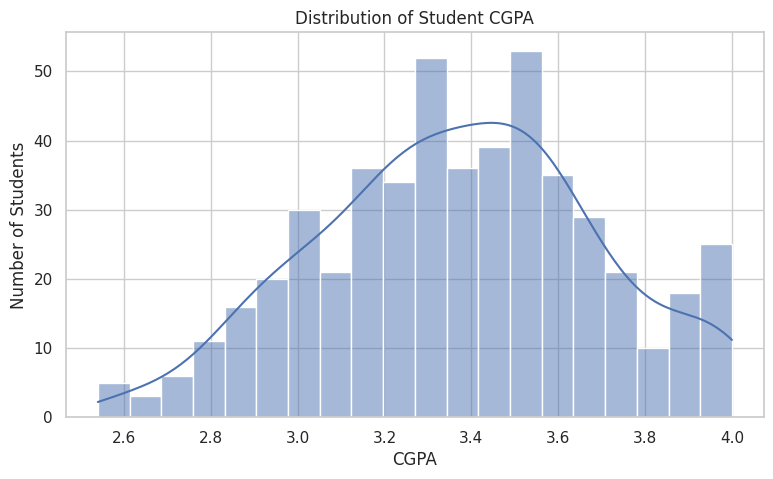

In [15]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="CGPA",
    bins=20,
    kde=True
)

plt.title("Distribution of Student CGPA")
plt.xlabel("CGPA")
plt.ylabel("Number of Students")
plt.show()



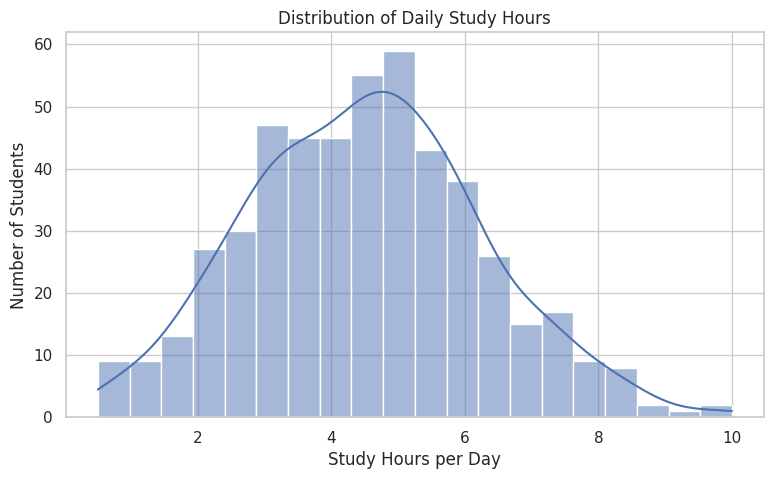

In [16]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Study_Hours",
    bins=20,
    kde=True
)

plt.title("Distribution of Daily Study Hours")
plt.xlabel("Study Hours per Day")
plt.ylabel("Number of Students")
plt.show()

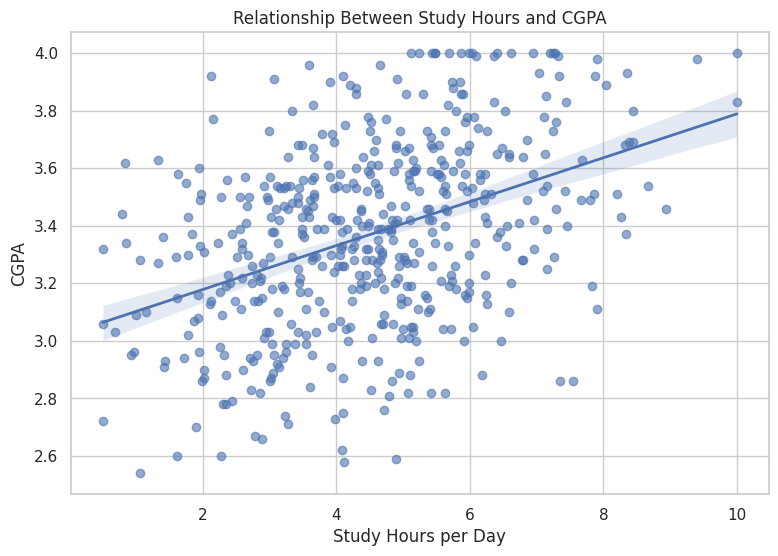

In [17]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="Study_Hours",
    y="CGPA",
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 2}
)

plt.title("Relationship Between Study Hours and CGPA")
plt.xlabel("Study Hours per Day")
plt.ylabel("CGPA")
plt.show()

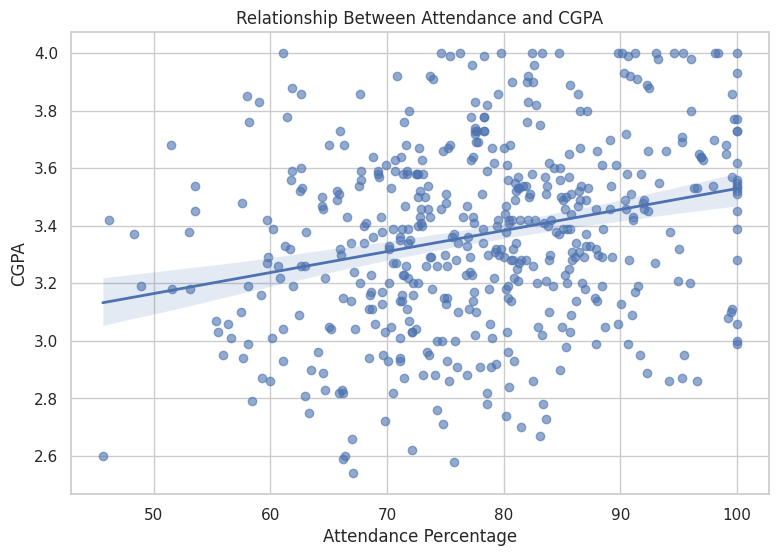

In [18]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="Attendance",
    y="CGPA",
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 2}
)

plt.title("Relationship Between Attendance and CGPA")
plt.xlabel("Attendance Percentage")
plt.ylabel("CGPA")
plt.show()

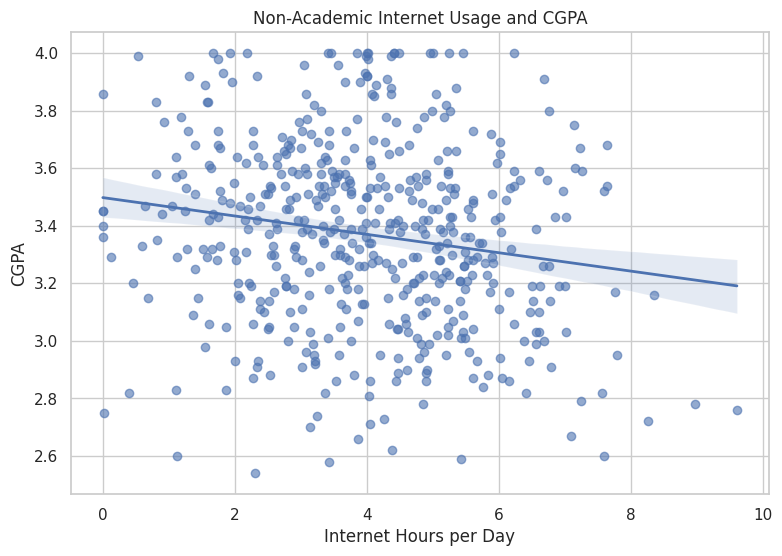

In [19]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="Internet_Hours",
    y="CGPA",
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 2}
)

plt.title("Non-Academic Internet Usage and CGPA")
plt.xlabel("Internet Hours per Day")
plt.ylabel("CGPA")
plt.show()

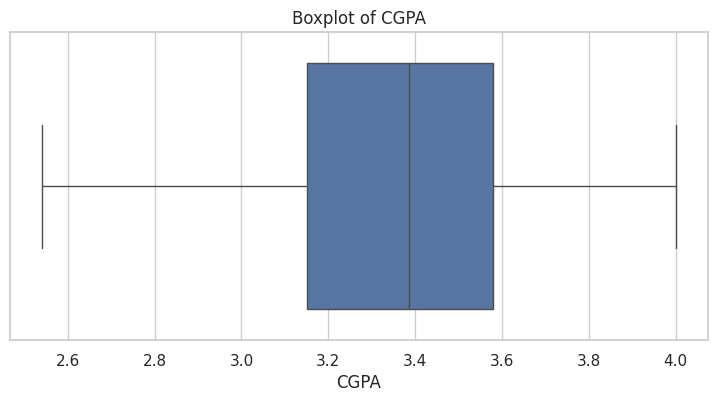

In [20]:
plt.figure(figsize=(9, 4))

sns.boxplot(
    data=df,
    x="CGPA"
)

plt.title("Boxplot of CGPA")
plt.xlabel("CGPA")
plt.show()

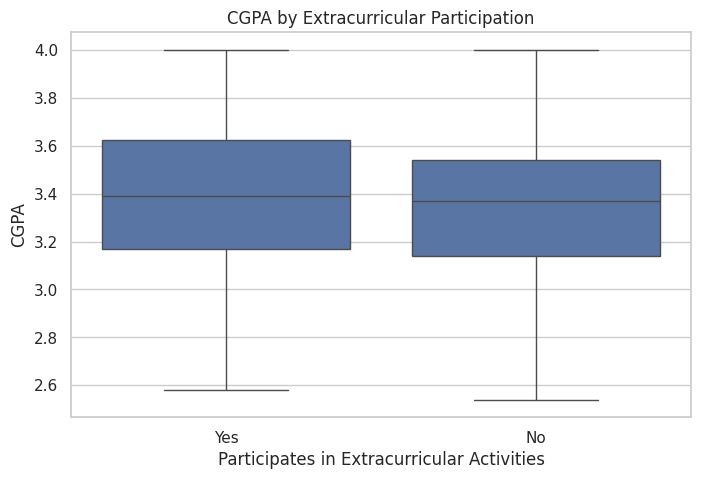

In [21]:


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Extracurricular",
    y="CGPA"
)

plt.title("CGPA by Extracurricular Participation")
plt.xlabel("Participates in Extracurricular Activities")
plt.ylabel("CGPA")
plt.show()



In [22]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=["number"])

# Student ID is only an identifier, so remove it from correlation analysis
numerical_df = numerical_df.drop(columns=["Student_ID"])

numerical_df.head()

,Study_Hours,Attendance,Assignment_Score,Sleep_Hours,Internet_Hours,Family_Income,Previous_GPA,CGPA
0,5.390,89.110,90.190,7.730,2.780,82120.000,2.140,3.460
1,4.250,100.000,84.020,6.140,3.740,102191.000,2.610,3.550
2,5.670,61.220,72.780,5.820,2.570,50005.000,2.810,3.330
3,7.240,84.760,63.590,6.800,3.450,42846.000,3.850,4.000
4,4.080,70.190,81.080,6.600,0.590,33033.000,3.250,3.330


In [23]:
cgpa_correlations = (
    numerical_df.corr()["CGPA"]
    .sort_values(ascending=False)
)

print("Correlation of each variable with CGPA:")
print(cgpa_correlations)

Correlation of each variable with CGPA:
CGPA                1.000
Previous_GPA        0.547
Study_Hours         0.413
Attendance          0.259
Sleep_Hours         0.216
Assignment_Score    0.185
Family_Income       0.118
Internet_Hours     -0.170
Name: CGPA, dtype: float64


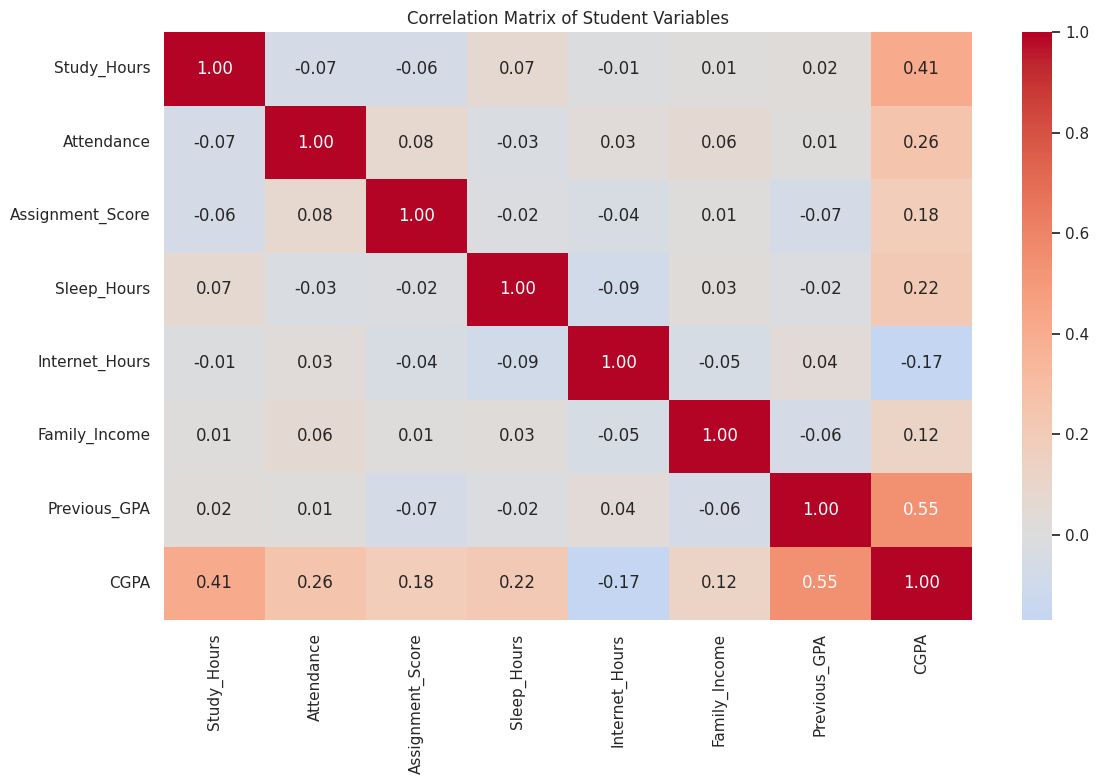

In [24]:
plt.figure(figsize=(12, 8))

correlation_matrix = numerical_df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Student Variables")
plt.tight_layout()
plt.show()